In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod
from neuron import h, gui

# 加载基础的 NEURON GUI 库
h.load_file("nrngui.hoc")

# 依次打开各个 HOC 文件
h.load_file("n128.hoc")               # 几何文件
h.load_file("axon_sections.hoc")      # 轴突部分
h.load_file("basal_dendrite.hoc")     # 基础树突
h.load_file("apical_dendrite.hoc")    # 顶端树突
h.load_file("apical_trunk.hoc")       # 顶端树干
h.load_file("radiatum.hoc")           # 放射区
h.load_file("init.hoc")               # 初始化设置
h.load_file("addgraph.hoc")           # 添加图形显示
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,
               ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', 
               ylabel = 'Frequency/Hz', label='',ynum_decimals =1, 
               nonscatter=True, s0=10):
    if nonscatter:
        if color:
            ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
        else:
            ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    else:
        if color:
            ax2.scatter(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, 
                        label=label, s=s0)
        else:
            ax2.scatter(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label,
                        s=s0)
        
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if dx:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

/home/wzl/anaconda/envs/neuron9/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
INFO : Using neuron-nightly Package (Developer Version)
/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/conductance
cfiles =
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/h.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/ICaL.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/ICaT.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/kadist.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/kaprox.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hipp

--No graphics will be displayed.


Check neuron_morph
	 Note: diam values less than 0.3um are set to 0.3um!
Diam was changed for: 0  points



# estimate $V_{rest}$ = -70

-70.00000069740193


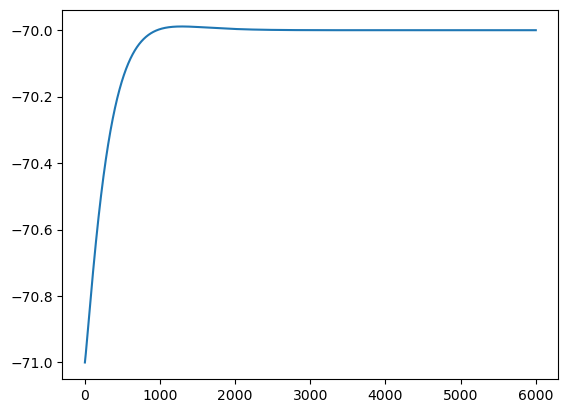

In [2]:
h.init()
run_dt = 0.1
h.dt = run_dt
h.tstop = 600.
h.v_init = -71
recv = h.Vector().record(h.soma(0.5)._ref_v)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()


go()
recv0 =  np.array(recv.to_python())
plt.plot(recv0)
print(recv0[5000])

In [3]:
h.soma.psection()

{'point_processes': {},
 'density_mechs': {'pas': {'g': [1.6666666666666667e-05],
   'e': [-71.64064333062406],
   'i': [2.7344055192747638e-05]},
  'hd': {'ghdbar': [2e-06],
   'vhalfl': [-73.0],
   'i': [-3.258667220577966e-05],
   'l': [0.40733340237337307]},
  'kap': {'gkabar': [0.0005],
   'gka': [1.9908635890123772e-07],
   'n': [0.0004796491893008756],
   'l': [0.8301332029470759]},
  'kdr': {'gkdrbar': [0.005],
   'gkdr': [4.110698968738662e-07],
   'n': [8.22139793757604e-05]},
  'na3': {'gbar': [0.03],
   'ar2': [1.0],
   'm': [0.012317107023497987],
   'h': [0.9933071491105357],
   's': [1.0]}},
 'ions': {'na': {'ena': [55.0],
   'nai': [10.0],
   'nao': [140.0],
   'ina': [-6.960508595126083e-06],
   'dina_dv_': [5.56840687527933e-08]},
  'k': {'ek': [-90.0],
   'ki': [54.4],
   'ko': [2.5],
   'ik': [1.2203125103872989e-05],
   'dik_dv_': [6.101562557773085e-07]}},
 'morphology': {'L': 0.0099945068359375,
  'diam': [18.079999923706055],
  'pts3d': [(-0.6890000104904175,
  

# estimate C and GL

In [12]:
def est_GL_C(run_dt):
   
    h.init()    
    h.dt = run_dt
    h.tstop = 600.
    h.v_init = -71.
        
    time = h.Vector().record(h._ref_t)
    recv = h.Vector().record(h.soma(0.5)._ref_v)
    

    # Initialize voltage clamp
    iclamp = h.IClamp(h.soma(0.5))
    iclamp.delay = 200.
    iclamp.dur = 200.
    iclamp.amp = 0.
    
    i_clamp = h.Vector().record(iclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()
        
    def verfication(GL, C, t, I):
        
        v = np.zeros(len(t))
        for i in range(len(t)-1):
            v[i+1] = v[i] + run_dt/C*(-GL*v[i]+I[i])
            
        return v
        
        
    # Main simulation loop
    def main():
    
        i_amp = np.arange(1,20)*0.001
        C = np.zeros(len(i_amp))
        GL = np.zeros(len(i_amp))
        iclamp.amp = 0.
        go()
        recv0 = np.array(recv.to_python())
        V_rest = recv0[-1]
        print(V_rest)
        
        for i in range(len(i_amp)):      
            iclamp.amp = i_amp[i]
            go()
            recv0 = np.array(recv.to_python())
            i0 = np.array(i_clamp.to_python())
            time0 = np.array(time.to_python())
            plt.plot(time0, recv0-V_rest, color='r')
            recv_norm = recv0 - V_rest
            GL[i] = i_amp[i]*1e-3/recv_norm[3999]
            
            y = np.log(recv_norm[4000:4300])
            A = np.ones((len(time0[4000:4300]),2))
            A[:,0] = time0[4000:4300]
            x, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
            tau_decay = -1./x[0] 
            C[i] = tau_decay*GL[i]
            v = verfication(GL[i], C[i], time0, i0*1e-3)
            # v_tune = verfication(0.011, 0.31, time0, i0)
            plt.plot(time0, v, 'b')
            plt.xlim([350,500])
            # plt.plot(time0, v_tune, 'k')
            # plt.legend()
        return  GL,C
    
    GL,C = main()
    return  GL,C

-70.00000001896488


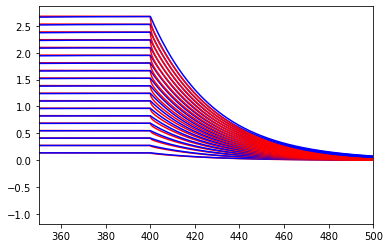

In [13]:
GL,C = est_GL_C(0.1)

In [14]:
print(np.mean(C))
print(np.mean(GL))

0.00020005749185943096
7.2133571213486236e-06


# estimate effective conductance

In [3]:
def eff_cond_est_two(run_dt, fE, fI, C = 0.0002, GL = 7.213e-6, locE=58, locI=37,
                         plot =False, psection = False):
    
    h.init()
    if psection:
       print(h.soma.psection()) 
    h.dt = run_dt
    h.tstop = 400.
    h.v_init = -71.
    Vclamp_init = -71.
    recv = h.Vector().record(h.soma(0.5)._ref_v)
    
    # Initialize an excitatory and inhibitory synaptic input
    # make a new stimulator
    stimE = h.NetStim()
    stimI = h.NetStim()

    synE = h.Exp2Syn(h.dend[int(locE)](0.5))
    synI = h.Exp2Syn(h.dend[int(locI)](0.5))
    synE.tau1 = 1.  # ms
    synE.tau2 = 5.  # ms
    synI.tau1 = 1.  # ms
    synI.tau2 = 5.  # ms

    synE.e = 0.  # mV for E input and -100 for I input 
    synI.e = -80.
        
    stimE.number = 1
    stimE.start = h.tstop - 100.  # ms
    stimI.number = 1
    stimI.start = h.tstop - 100.  # ms
    ncstimE = h.NetCon(stimE, synE)
    ncstimE.delay = 0.
    ncstimE.weight[0] = 0e-2  # uS
    ncstimI = h.NetCon(stimI, synI)
    ncstimI.delay = 0.
    ncstimI.weight[0] = 0e-2  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(h.soma(0.5))
    vclamp.amp1 = Vclamp_init
    vclamp.dur1 = h.tstop
    vclamp.dur2 = h.tstop
    vclamp.amp2 = Vclamp_init - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():

        Vclamp = np.arange(-110.,-60.,10)
        tstart = int(stimI.start/run_dt+1)

        V_rest = -70. # mV
        epsilonE = 0. - V_rest
        epsilonI = -80. - V_rest
        epsilonI1 = -100. - V_rest
        
        
        #  pure E for the estimation of true GE_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = fE
        ncstimI.weight[0] = 0.
        go()
        recvE0 = np.array(recv.to_python())
        recvE0_norm = recvE0[tstart:tstart+1000] - V_rest
        dVdtE = np.diff(recvE0_norm)/run_dt
        dVdtE = np.append(dVdtE, 0)
        GE_est = (C*dVdtE + GL*recvE0_norm)/(epsilonE - recvE0_norm)
        
        #  pure I input for the estimation of GI_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = 0.
        ncstimI.weight[0] = fI
        go()
        recvI0 = np.array(recv.to_python())
        recvI0_norm = recvI0[tstart:tstart+1000] - V_rest
        dVdtI = np.diff(recvI0_norm)/run_dt
        dVdtI = np.append(dVdtI, 0)
        GI_est = (C*dVdtI + GL*recvI0_norm)/(epsilonI - recvI0_norm)
        if plot:
            # plt.plot(recvE0_norm, 'r')
            plt.plot(recvE0, 'r')
            # plt.plot(recvI0_norm, 'b')
            plt.plot(recvI0, 'b')
        
        
    
        Isyn_inj_t = np.zeros((len(Vclamp),1000))
        Isyn_epsilonI1_inj_t = np.zeros((len(Vclamp),1000))

        

        for i in range(len(Vclamp)):
            ncstimE.weight[0] = 0.
            ncstimI.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            
            synE.e = 0.
            synI.e = -80.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn = (Iinj1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_inj_t[i,:] = Isyn
            
            synE.e = 0.
            synI.e = -100.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1_epsilonI1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn_epsilonI1 =  (Iinj1_epsilonI1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_epsilonI1_inj_t[i,:] = Isyn_epsilonI1
            
                                                         
        traditional_effective_conductance = np.zeros((2,1000))
        intercept_effective_conductance = np.zeros((2,1000))
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        epsilonE = 0. - V_rest
        epsilonI = -80. - V_rest
        epsilonI1 = -100. - V_rest
        for i in range(1000):
            x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj_t[:,i], 
                                                                  rcond=None)
            x_epsilonI1, residuals, rank, singular_values = np.linalg.lstsq(A, 
                                Isyn_epsilonI1_inj_t[:,i], rcond=None)
            
            traditional_effective_conductance[1, i] = (x[0]*epsilonE + x[1])/(epsilonE - epsilonI)
            traditional_effective_conductance[0, i] = (x[0]*epsilonI + x[1])/(epsilonI - epsilonE)
           
            intercept_effective_conductance[1,i] = (x[1] - x_epsilonI1[1])/(epsilonI1 - epsilonI)
            intercept_effective_conductance[0,i] = (-intercept_effective_conductance[1,i]*epsilonI - x[1])/epsilonE
            
        
        return intercept_effective_conductance, traditional_effective_conductance, GE_est, GI_est
    
    
    intercept_effective_conductance, traditional_effective_conductance,GE_est, GI_est = main()
    return intercept_effective_conductance, traditional_effective_conductance,GE_est, GI_est

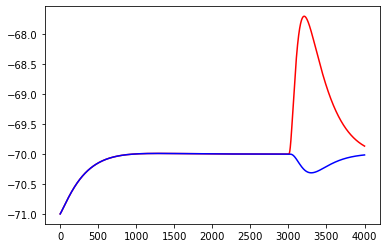

In [9]:
intercept_effective_conductance, traditional_effective_conductance,GE_est, GI_est = eff_cond_est_two(0.1,
5e-3, 5e-3,locE = 100, locI = 120, plot =True, psection = False)

# data analysis

In [7]:
from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位
def plot_curve(ax2,x,y,color='black',title='', linestyle='-',linewidth=2, xlim=[0,100],dx=20,
               ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', 
               ylabel = 'Frequency/Hz', label='',ynum_decimals =1, facecolors='none',
               nonscatter=True, s0=10, facecolor='none'):
    if nonscatter:
        if color:
            ax2.plot(x,y,color=color,linewidth=linewidth,linestyle=linestyle,alpha=alpha, label=label)
        else:
            ax2.plot(x,y,linewidth=linewidth,alpha=alpha, linestyle=linestyle,label=label)
    else:
        if color:
            ax2.scatter(x,y,edgecolors=color,facecolors = facecolor, alpha=alpha, 
                        label=label, s=s0)
        else:
            ax2.scatter(x,y, alpha=alpha, label=label,
                        s=s0)
        
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
        # ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


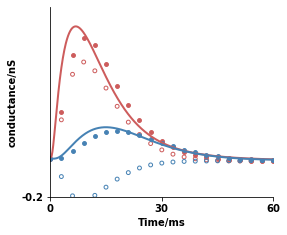

In [8]:
time = np.arange(0,len(GE_est))*0.1
s0 = 15
fig, ax2 = plt.subplots(1,1, figsize = (4,3.5))
plot_curve(ax2,time, GE_est*1e6, color='indianred', label='',
               xlim=[0,100], dx=50, linewidth=2, 
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS')

plot_curve(ax2,time[::30], intercept_effective_conductance[0,::30]*1e3, color='indianred',label='',
               xlim=[0,100], dx=50,
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='indianred')

plot_curve(ax2, time[::30], traditional_effective_conductance[0,::30]*1e3, color='indianred',label='',
               xlim=[0,1000], dx=500,
               ylim=[0, 2], dy  =0., ynum_decimals=1, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='none')

plot_curve(ax2,time, GI_est*1e6,color='steelblue',label='',
               xlim=[0,100], dx=50,linewidth=2, 
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS')

plot_curve(ax2, time[::30], 
           intercept_effective_conductance[1,::30]*1e3,color='steelblue',label='',
               xlim=[0,100], dx=50,
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='steelblue')

plot_curve(ax2, time[::30], 
           traditional_effective_conductance[1,::30]*1e3,color='steelblue',label='',
               xlim=[0,60], dx=30,
               ylim=[-0.2, 0.8], dy = 2., ynum_decimals=1, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='none')
# plt.savefig("/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/figure/figure4/pairEI_eff_con.eps", format='eps', dpi=300)
plt.show()
# ax2[1].set_title('active I')e-4, 6e-4, locE=58, locI=37, plot = True, psection =True)

# parallel

In [ ]:
def error_eff_cond_est_two(run_dt, fE, fI, C = 0.0002, GL = 7.213e-6, 
                           locE=58, locI=37):
    
    h.init()
    h.dt = run_dt
    h.tstop = 400.
    h.v_init = -71.
    Vclamp_init = -71.
    recv = h.Vector().record(h.soma(0.5)._ref_v)
    
    # Initialize an excitatory and inhibitory synaptic input
    # make a new stimulator
    stimE = h.NetStim()
    stimI = h.NetStim()

    synE = h.Exp2Syn(h.dend[int(locE)](0.5))
    synI = h.Exp2Syn(h.dend[int(locI)](0.5))
    synE.tau1 = 1.  # ms
    synE.tau2 = 5.  # ms
    synI.tau1 = 1.  # ms
    synI.tau2 = 5.  # ms

    synE.e = 0.  # mV for E input and -100 for I input 
    synI.e = -80.
        
    stimE.number = 1
    stimE.start = h.tstop - 100.  # ms
    stimI.number = 1
    stimI.start = h.tstop - 100.  # ms
    ncstimE = h.NetCon(stimE, synE)
    ncstimE.delay = 0.
    ncstimE.weight[0] = 0e-2  # uS
    ncstimI = h.NetCon(stimI, synI)
    ncstimI.delay = 0.
    ncstimI.weight[0] = 0e-2  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(h.soma(0.5))
    vclamp.amp1 = Vclamp_init
    vclamp.dur1 = h.tstop
    vclamp.dur2 = h.tstop
    vclamp.amp2 = Vclamp_init - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():

        Vclamp = np.arange(-110.,-60.,10)
        tstart = int(stimI.start/run_dt+1)

        V_rest = -70. # mV
        epsilonE = 0. - V_rest
        epsilonI = -80. - V_rest
        epsilonI1 = -100. - V_rest
        
        
        #  pure E for the estimation of true GE_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = fE
        ncstimI.weight[0] = 0.
        go()
        recvE0 = np.array(recv.to_python())
        recvE0_norm = recvE0[tstart:tstart+1000] - V_rest
        dVdtE = np.diff(recvE0_norm)/run_dt
        dVdtE = np.append(dVdtE, 0)
        GE_est = (C*dVdtE + GL*recvE0_norm)/(epsilonE - recvE0_norm)
        
        #  pure I input for the estimation of GI_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = 0.
        ncstimI.weight[0] = fI
        go()
        recvI0 = np.array(recv.to_python())
        recvI0_norm = recvI0[tstart:tstart+1000] - V_rest
        dVdtI = np.diff(recvI0_norm)/run_dt
        dVdtI = np.append(dVdtI, 0)
        GI_est = (C*dVdtI + GL*recvI0_norm)/(epsilonI - recvI0_norm)

        
        
    
        Isyn_inj_t = np.zeros((len(Vclamp),1000))
        Isyn_epsilonI1_inj_t = np.zeros((len(Vclamp),1000))

        

        for i in range(len(Vclamp)):
            ncstimE.weight[0] = 0.
            ncstimI.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            
            synE.e = 0.
            synI.e = -80.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn = (Iinj1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_inj_t[i,:] = Isyn
            
            synE.e = 0.
            synI.e = -100.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1_epsilonI1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn_epsilonI1 =  (Iinj1_epsilonI1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_epsilonI1_inj_t[i,:] = Isyn_epsilonI1
            
                                                         
        traditional_effective_conductance = np.zeros((2,1000))
        intercept_effective_conductance = np.zeros((2,1000))
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        epsilonE = 0. - V_rest
        epsilonI = -80. - V_rest
        epsilonI1 = -100. - V_rest
        for i in range(1000):
            x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj_t[:,i], 
                                                                  rcond=None)
            x_epsilonI1, residuals, rank, singular_values = np.linalg.lstsq(A, 
                                Isyn_epsilonI1_inj_t[:,i], rcond=None)
            
            traditional_effective_conductance[1, i] = (x[0]*epsilonE + x[1])/(epsilonE - epsilonI)
            traditional_effective_conductance[0, i] = (x[0]*epsilonI + x[1])/(epsilonI - epsilonE)
           
            intercept_effective_conductance[1,i] = (x[1] - x_epsilonI1[1])/(epsilonI1 - epsilonI)
            intercept_effective_conductance[0,i] = (-intercept_effective_conductance[1,i]*epsilonI - x[1])/epsilonE
        relative_error = np.zeros(4) 
        relative_error[0] = np.linalg.norm(GE_est*1e6-intercept_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
        relative_error[1] = np.linalg.norm(GE_est*1e6-traditional_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
        relative_error[2] = np.linalg.norm(GI_est*1e6-intercept_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
        relative_error[3] = np.linalg.norm(GI_est*1e6-traditional_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
        
        
        GE_est_norm = GE_est*1e6
        GI_est_norm = GI_est*1e6
        GE_est_inter = intercept_effective_conductance[0,:]*1e3  
        GE_est_trad = traditional_effective_conductance[0,:]*1e3
        GI_est_inter = intercept_effective_conductance[1,:]*1e3 
        GI_est_trad = traditional_effective_conductance[1,:]*1e3  
        return relative_error, GE_est_norm, GI_est_norm, GE_est_inter, GE_est_trad, GI_est_inter, GI_est_trad
    
    
    relative_error, GE_est_norm, GI_est_norm, GE_est_inter, GE_est_trad, GI_est_inter, GI_est_trad= main()
    N = len(relative_error) + len(GE_est_norm) + len(GI_est_norm) + len(GE_est_inter) + len(GE_est_trad) + len(GI_est_inter) + len(GI_est_trad)
    N1 = len(relative_error)
    N2 = N1 + len(GE_est_norm)
    N3 = N2 + len(GI_est_norm)
    N4 = N3 + len(GE_est_inter)
    N5 = N4 + len(GE_est_trad)
    N6 = N5 + len(GI_est_inter)
    N7 = N6 + len(GI_est_trad)
    results = np.zeros(N)
    results[:N1] = relative_error
    results[N1:N2] = GE_est_norm
    results[N2:N3] = GI_est_norm
    results[N3:N4] = GE_est_inter
    results[N4:N5] = GE_est_trad
    results[N5:N6] = GI_est_inter
    results[N6:N7] = GI_est_trad
    return results


In [5]:
results = error_eff_cond_est_two(0.1, 1e-3, 1e-3, C = 0.0002, GL = 7.213e-6, 
                           locE=58, locI=37)

In [7]:
# Your existing functions and code
def error_eff_cond_est_two_parallel(args,):
    stimu0, = args
    results = error_eff_cond_est_two(0.1, 1e-3, 1e-3, C = 0.0002, GL = 7.213e-6, 
                           locE=stimu0[0], locI=stimu0[1])
     
    return results

loc = np.arange(0,199,1)
stimu =[]
for i in range(len(loc)):
    for j in range(len(loc)):
        stimu.append([loc[i],loc[j]])

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 55
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(stimu0,) for stimu0 in stimu]

    # Apply the function in parallel
    results = pool.map(error_eff_cond_est_two_parallel, args_list)

results_total = np.zeros((len(stimu), 6004))

for i, result in enumerate(results):loc = np.arange(0,199,1)
stimu =[]
for i in range(len(loc)):
    for j in range(len(loc)):
        stimu.append([loc[i],loc[j]])

    results_total[i, :] = result
np.savetxt("pair_eff_cond_E1e3_I1e3_whole.txt", results_total)

In [3]:
results_total = np.loadtxt("pair_eff_cond_E1e3_I1e3_whole.txt")
relative_error = results_total[:, :4]
GE_est_norm = results_total[:, 4:1004]
GI_est_norm = results_total[:, 1004:2004]
GE_est_inter = results_total[:, 2004:3004]
GE_est_trad = results_total[:, 3004:4004]
GI_est_inter = results_total[:, 4004:5004]
GI_est_trad = results_total[:, 5004:6004]
# mean error
error_mean = np.zeros_like(relative_error)
error_mean[:,0] = np.abs(np.mean(GE_est_norm,axis=1) - np.mean(GE_est_inter, axis=1))/np.mean(GE_est_norm,axis=1)
error_mean[:,1] = np.abs(np.mean(GE_est_norm,axis=1) - np.mean(GE_est_trad, axis=1))/np.mean(GE_est_norm,axis=1)
error_mean[:,2] = np.abs(np.mean(GI_est_norm,axis=1) - np.mean(GI_est_inter, axis=1))/np.mean(GI_est_norm,axis=1)
error_mean[:,3] = np.abs(np.mean(GI_est_norm,axis=1) - np.mean(GI_est_trad, axis=1))/np.mean(GI_est_norm,axis=1)
GE_est_inter_mean = np.mean(GE_est_inter, axis=1)
GE_est_norm_mean = np.mean(GE_est_norm, axis=1)
GI_est_norm_mean = np.mean(GI_est_norm, axis=1)
GE_est_trad_mean = np.mean(GE_est_trad, axis=1)
GI_est_inter_mean = np.mean(GI_est_inter, axis=1)
GI_est_trad_mean = np.mean(GI_est_trad, axis=1)
negative_GE_est_inter = np.sum(GE_est_inter_mean<0)
negative_GE_est_trad = np.sum(GE_est_trad_mean<0)
negative_GI_est_inter = np.sum(GI_est_inter_mean<0)
negative_GI_est_trad = np.sum(GI_est_trad_mean<0)
negative_GE_est_norm = np.sum(GE_est_norm_mean<0)
negative_GI_est_norm = np.sum(GI_est_norm_mean<0)
print(negative_GE_est_norm)
print(negative_GI_est_norm)
print(np.mean(error_mean,axis=0))


0
0
[0.05715063 0.23997717 0.03132271 0.73436496]


In [1]:
print(np.max(error_mean,axis=0))

NameError: name 'np' is not defined

(39601, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


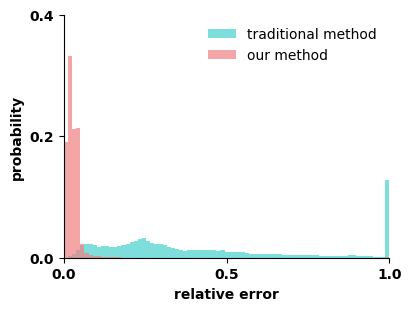

In [7]:
# distance = np.loadtxt('pairEI_distance.txt')
# relative_error = np.loadtxt('pair_eff_cond_relative_error_E6e3_I3e3_whole.txt')

error = error_mean
# print(np.shape(distance))
print(np.shape(error))
fontsize = 10
bins = np.linspace(0,1,80)


# 定义误差和 bin 范围
min_bin = bins[0]  # bins的最小值
max_bin = bins[-1]  # bins的最大值

# 将 error 限制在 [min_bin, max_bin] 之间
clipped_error_our = np.clip(error[:,2], min_bin, max_bin)
clipped_error_trad = np.clip(error[:,3], min_bin, max_bin)

fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(clipped_error_our,bins=bins)
nE_trad,binsE_trad = np.histogram(clipped_error_trad,bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0,1.2,0.5))
ax1.set_yticks(np.arange(0,0.5,0.2))
ax1.set_xticklabels(np.arange(0,1.2,0.5),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.5,0.2),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.4])
ax1.set_xlim([0,1])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_I.eps')

(39601, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


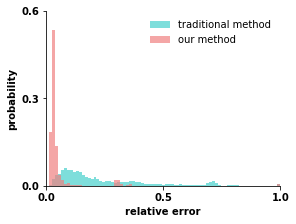

In [13]:
# distance = np.loadtxt('pairEI_distance.txt')
# relative_error = np.loadtxt('pair_eff_cond_relative_error_E6e3_I3e3_whole.txt')

error = error_mean
# print(np.shape(distance))
print(np.shape(error))
fontsize = 10
bins = np.linspace(0,1,80)
fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(error[:,0],bins=bins)
nE_trad,binsE_trad = np.histogram(error[:,1],bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0,1.2,0.5))
ax1.set_yticks(np.arange(0,0.7,0.3))
ax1.set_xticklabels(np.arange(0,1.2,0.5),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.7,0.3),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.6])
ax1.set_xlim([0,1])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_E.eps')

[0.         0.12608267]


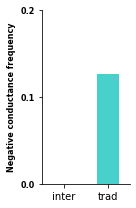

In [16]:
import matplotlib.pyplot as plt


y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GI_est_inter_mean)
x_values = ['inter', 'trad']
# y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)
print(y_values)


# 指定每个条形的位置
positions = [1.5, 2.5]  # 注意x1和x2之间的距离小于x2和x3之间的距离

fig, ax = plt.subplots(1,1, figsize = (2,3))
ax.bar(positions, y_values, tick_label=x_values, color = ['lightcoral',  'mediumturquoise'],width=0.5)

# 添加标签和标题
# plt.xlabel('Variables')
ylim=[0,0.2]
dy=0.1
fontsize=8
ynum_decimals = 1
ax.set_ylabel('Negative conductance frequency', fontsize=fontsize, weight='bold')
ax.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
ax.set_yticklabels(ax.get_yticks(), fontsize=fontsize, weight='bold')
ax.set_ylim([ylim[0], ylim[1]])
ax.set_xlim([1, 3])
def format_funcy(value, tick_number, num_decimals=ynum_decimals):
    if num_decimals==0:
        return f'{value:.0f}'
    return f'{value:.{num_decimals}f}'
ax.yaxis.set_major_formatter(FuncFormatter(format_funcy))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("negative_distr_I.eps", format='eps', dpi=300)
